# Mapping income, housing cost, and arrest data in LA County.
## For this part of the project, I am interested in mapping both income and hosuing cost disparities in LA County and spatially relating this to the Million Dollar Hoods data, which shows that South Central and Downtown LA are the two most policed areas in the county. I will be using census data and the LAPD's arrest data to explore the spatial relation between income, housing costs, and arrests. 
### One note on housing costs: for the purposes of this project, I am interested in housing costs as a percentage of median household income in each census tract.

In [1]:
import os
os.chdir('/home/jovyan/221-final-project/Group Assignments/Income')

In [2]:
!pip install RISE

  Using cached rise-5.7.1-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached rise-5.7.1-py2.py3-none-any.whl (4.3 MB)


### Importing income data for LA County

In [3]:
import pandas as pd

In [4]:
import geopandas as gpd

In [5]:
df = pd.read_csv('/home/jovyan/221-final-project/Group Assignments/Income/data/findata/ACSST5Y2023.S2503-Data.csv', low_memory=False)

In [6]:
df.shape

(2499, 555)

In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [8]:
df.sample(5)

,GEO_ID,NAME,S2503_C01_001E,S2503_C01_001M,S2503_C01_002E,S2503_C01_002M,S2503_C01_003E,S2503_C01_003M,S2503_C01_004E,S2503_C01_004M,S2503_C01_005E,S2503_C01_005M,S2503_C01_006E,S2503_C01_006M,S2503_C01_007E,S2503_C01_007M,S2503_C01_008E,S2503_C01_008M,S2503_C01_009E,S2503_C01_009M,S2503_C01_010E,S2503_C01_010M,S2503_C01_011E,S2503_C01_011M,S2503_C01_012E,S2503_C01_012M,S2503_C01_013E,S2503_C01_013M,S2503_C01_014E,S2503_C01_014M,S2503_C01_015E,S2503_C01_015M,S2503_C01_016E,S2503_C01_016M,S2503_C01_017E,S2503_C01_017M,S2503_C01_018E,S2503_C01_018M,S2503_C01_019E,S2503_C01_019M,S2503_C01_020E,S2503_C01_020M,S2503_C01_021E,S2503_C01_021M,S2503_C01_022E,S2503_C01_022M,S2503_C01_023E,S2503_C01_023M,S2503_C01_024E,S2503_C01_024M,S2503_C01_025E,S2503_C01_025M,S2503_C01_026E,S2503_C01_026M,S2503_C01_027E,S2503_C01_027M,S2503_C01_028E,S2503_C01_028M,S2503_C01_029E,S2503_C01_029M,S2503_C01_030E,S2503_C01_030M,S2503_C01_031E,S2503_C01_031M,S2503_C01_032E,S2503_C01_032M,S2503_C01_033E,S2503_C01_033M,S2503_C01_034E,S2503_C01_034M,S2503_C01_035E,S2503_C01_035M,S2503_C01_036E,S2503_C01_036M,S2503_C01_037E,S2503_C01_037M,S2503_C01_038E,S2503_C01_038M,S2503_C01_039E,S2503_C01_039M,S2503_C01_040E,S2503_C01_040M,S2503_C01_041E,S2503_C01_041M,S2503_C01_042E,S2503_C01_042M,S2503_C01_043E,S2503_C01_043M,S2503_C01_044E,S2503_C01_044M,S2503_C01_045E,S2503_C01_045M,S2503_C01_046E,S2503_C01_046M,S2503_C02_001E,S2503_C02_001M,S2503_C02_002E,S2503_C02_002M,S2503_C02_003E,S2503_C02_003M,S2503_C02_004E,S2503_C02_004M,S2503_C02_005E,S2503_C02_005M,S2503_C02_006E,S2503_C02_006M,S2503_C02_007E,S2503_C02_007M,S2503_C02_008E,S2503_C02_008M,S2503_C02_009E,S2503_C02_009M,S2503_C02_010E,S2503_C02_010M,S2503_C02_011E,S2503_C02_011M,S2503_C02_012E,S2503_C02_012M,S2503_C02_013E,S2503_C02_013M,S2503_C02_014E,S2503_C02_014M,S2503_C02_015E,S2503_C02_015M,S2503_C02_016E,S2503_C02_016M,S2503_C02_017E,S2503_C02_017M,S2503_C02_018E,S2503_C02_018M,S2503_C02_019E,S2503_C02_019M,S2503_C02_020E,S2503_C02_020M,S2503_C02_021E,S2503_C02_021M,S2503_C02_022E,S2503_C02_022M,S2503_C02_023E,S2503_C02_023M,S2503_C02_024E,S2503_C02_024M,S2503_C02_025E,S2503_C02_025M,S2503_C02_026E,S2503_C02_026M,S2503_C02_027E,S2503_C02_027M,S2503_C02_028E,S2503_C02_028M,S2503_C02_029E,S2503_C02_029M,S2503_C02_030E,S2503_C02_030M,S2503_C02_031E,S2503_C02_031M,S2503_C02_032E,S2503_C02_032M,S2503_C02_033E,S2503_C02_033M,S2503_C02_034E,S2503_C02_034M,S2503_C02_035E,S2503_C02_035M,S2503_C02_036E,S2503_C02_036M,S2503_C02_037E,S2503_C02_037M,S2503_C02_038E,S2503_C02_038M,S2503_C02_039E,S2503_C02_039M,S2503_C02_040E,S2503_C02_040M,S2503_C02_041E,S2503_C02_041M,S2503_C02_042E,S2503_C02_042M,S2503_C02_043E,S2503_C02_043M,S2503_C02_044E,S2503_C02_044M,S2503_C02_045E,S2503_C02_045M,S2503_C02_046E,S2503_C02_046M,S2503_C03_001E,S2503_C03_001M,S2503_C03_002E,S2503_C03_002M,S2503_C03_003E,S2503_C03_003M,S2503_C03_004E,S2503_C03_004M,S2503_C03_005E,S2503_C03_005M,S2503_C03_006E,S2503_C03_006M,S2503_C03_007E,S2503_C03_007M,S2503_C03_008E,S2503_C03_008M,S2503_C03_009E,S2503_C03_009M,S2503_C03_010E,S2503_C03_010M,S2503_C03_011E,S2503_C03_011M,S2503_C03_012E,S2503_C03_012M,S2503_C03_013E,S2503_C03_013M,S2503_C03_014E,S2503_C03_014M,S2503_C03_015E,S2503_C03_015M,S2503_C03_016E,S2503_C03_016M,S2503_C03_017E,S2503_C03_017M,S2503_C03_018E,S2503_C03_018M,S2503_C03_019E,S2503_C03_019M,S2503_C03_020E,S2503_C03_020M,S2503_C03_021E,S2503_C03_021M,S2503_C03_022E,S2503_C03_022M,S2503_C03_023E,S2503_C03_023M,S2503_C03_024E,S2503_C03_024M,S2503_C03_025E,S2503_C03_025M,S2503_C03_026E,S2503_C03_026M,S2503_C03_027E,S2503_C03_027M,S2503_C03_028E,S2503_C03_028M,S2503_C03_029E,S2503_C03_029M,S2503_C03_030E,S2503_C03_030M,S2503_C03_031E,S2503_C03_031M,S2503_C03_032E,S2503_C03_032M,S2503_C03_033E,S2503_C03_033M,S2503_C03_034E,S2503_C03_034M,S2503_C03_035E,S2503_C03_035M,S2503_C03_036E,S2503_C03_036M,S2503_C03_037E,S2503_C03_037M,S2503_C03_038E,S2503_C03_038M,S2503_C03_039E,S2503_C03_039M,S2503_C03_040E,S2503_C03_040M,S2503_C03_041E,S2503_C03_04

In [9]:
df.GEO_ID.head()

0               Geography
1    1400000US06037101110
2    1400000US06037101122
3    1400000US06037101220
4    1400000US06037101221
Name: GEO_ID, dtype: object

### Extracting FIPS codes

In [10]:
df['FIPS'] = df['GEO_ID'].str[-11:]

In [11]:
print(df[['GEO_ID', 'FIPS']].head())

                 GEO_ID         FIPS
0             Geography    Geography
1  1400000US06037101110  06037101110
2  1400000US06037101122  06037101122
3  1400000US06037101220  06037101220
4  1400000US06037101221  06037101221


### Cleaning and reducing data

In [12]:
df.columns[df.isna().all()].tolist()

['Unnamed: 554']

In [13]:
df = df.dropna(axis=1,how="all")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2499 entries, 0 to 2498
Columns: 555 entries, GEO_ID to FIPS
dtypes: object(555)
memory usage: 10.6+ MB


In [15]:
columns_to_keep = ['FIPS',
                   'S2503_C01_013E',
                   'S2503_C01_024E',
                   'S2503_C02_013E',
                   'S2503_C02_024E',
                   'S2503_C03_013E',
                   'S2503_C03_024E',
                   'S2503_C04_013E',
                   'S2503_C04_024E',
                   'S2503_C05_013E',
                   'S2503_C05_024E',
                    'S2503_C06_013E',
                   'S2503_C06_024E']
df2 = df[columns_to_keep]

In [16]:
df2.columns= ['FIPS',
'MedHHIncome_All',
'MonthlyCosts_All',
'MedHHIncome_OwnerOccupied',
'MonthlyCosts_OwnerOccupied',
'MedHHIncome_RenterOccupied',
'MonthlyCosts_RenterOccupied',
'MedHHIncome_Mixed',
'MonthlyCosts_Mixed',
'MedHHIncome_NoMortgage',
'MonthlyCosts_NoMortgage',
'MedHHIncome_Mortgage',
'MonthlyCosts_Mortgage']





In [17]:
df2.sample(5)

,FIPS,MedHHIncome_All,MonthlyCosts_All,MedHHIncome_OwnerOccupied,MonthlyCosts_OwnerOccupied,MedHHIncome_RenterOccupied,MonthlyCosts_RenterOccupied,MedHHIncome_Mixed,MonthlyCosts_Mixed,MedHHIncome_NoMortgage,MonthlyCosts_NoMortgage,MedHHIncome_Mortgage,MonthlyCosts_Mortgage
691,06037214503,92431,2902,92431,2902,-,-,-,-,92431,2902,92431,2902
1732,06037534501,62083,1574,62083,1574,-,-,-,-,59643,1665,59643,1665
1861,06037551401,85938,1977,85938,1977,119181,2702,119181,2702,69656,1751,69656,1751
647,06037211310,46966,1542,46966,1542,143828,2701,143828,2701,45677,1524,45677,1524
324,06037135111,101157,2399,101157,2399,101964,2706,101964,2706,100943,2316,100943,2316


In [18]:
print (df2.dtypes)

FIPS                           object
MedHHIncome_All                object
MonthlyCosts_All               object
MedHHIncome_OwnerOccupied      object
MonthlyCosts_OwnerOccupied     object
MedHHIncome_RenterOccupied     object
MonthlyCosts_RenterOccupied    object
MedHHIncome_Mixed              object
MonthlyCosts_Mixed             object
MedHHIncome_NoMortgage         object
MonthlyCosts_NoMortgage        object
MedHHIncome_Mortgage           object
MonthlyCosts_Mortgage          object
dtype: object


In [19]:
columns_to_convert = ['MedHHIncome_All',
'MonthlyCosts_All',
'MedHHIncome_OwnerOccupied',
'MonthlyCosts_OwnerOccupied',
'MedHHIncome_RenterOccupied',
'MonthlyCosts_RenterOccupied',
'MedHHIncome_Mixed',
'MonthlyCosts_Mixed',
'MedHHIncome_NoMortgage',
'MonthlyCosts_NoMortgage',
'MedHHIncome_Mortgage',
'MonthlyCosts_Mortgage']


In [20]:
# Ensure df2 is an independent copy before modifying
df2 = df2.copy()

# Convert all columns except "FIPS" to numeric
columns_to_convert = [col for col in df2.columns if col != "FIPS"]
df2.loc[:, columns_to_convert] = df2[columns_to_convert].apply(pd.to_numeric, errors="coerce")

In [21]:
df2.dtypes

FIPS                           object
MedHHIncome_All                object
MonthlyCosts_All               object
MedHHIncome_OwnerOccupied      object
MonthlyCosts_OwnerOccupied     object
MedHHIncome_RenterOccupied     object
MonthlyCosts_RenterOccupied    object
MedHHIncome_Mixed              object
MonthlyCosts_Mixed             object
MedHHIncome_NoMortgage         object
MonthlyCosts_NoMortgage        object
MedHHIncome_Mortgage           object
MonthlyCosts_Mortgage          object
dtype: object

### Mapping Income Data

In [22]:
pip install geopandas folium matplotlib

Note: you may need to restart the kernel to use updated packages.


In [23]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
tracts=gpd.read_file('data/Census_Tracts_2020.geojson')
tracts.head()

,OBJECTID,CT20,LABEL,ShapeSTArea,ShapeSTLength,geometry
0,1,101110,1011.10,1.229562e+07,15083.854287,"POLYGON ((-118.28491 34.25948, -118.28492 34.2..."
1,2,101122,1011.22,2.845774e+07,31671.455844,"POLYGON ((-118.29015 34.27417, -118.29015 34.2..."
2,3,101220,1012.20,7.522093e+06,12698.783810,"POLYGON ((-118.281 34.25592, -118.28198 34.255..."
3,4,101221,1012.21,3.812000e+06,9161.710543,"POLYGON ((-118.28735 34.25591, -118.28863 34.2..."
4,5,101222,1012.22,3.191371e+06,9980.600461,"POLYGON ((-118.28594 34.25405, -118.28594 34.2..."


In [25]:
tracts = tracts[['CT20','geometry']]
tracts.head()

,CT20,geometry
0,101110,"POLYGON ((-118.28491 34.25948, -118.28492 34.2..."
1,101122,"POLYGON ((-118.29015 34.27417, -118.29015 34.2..."
2,101220,"POLYGON ((-118.281 34.25592, -118.28198 34.255..."
3,101221,"POLYGON ((-118.28735 34.25591, -118.28863 34.2..."
4,101222,"POLYGON ((-118.28594 34.25405, -118.28594 34.2..."


In [26]:
tracts['FIPS'] ='06' + '037' + tracts['CT20']
tracts.head()

,CT20,geometry,FIPS
0,101110,"POLYGON ((-118.28491 34.25948, -118.28492 34.2...",06037101110
1,101122,"POLYGON ((-118.29015 34.27417, -118.29015 34.2...",06037101122
2,101220,"POLYGON ((-118.281 34.25592, -118.28198 34.255...",06037101220
3,101221,"POLYGON ((-118.28735 34.25591, -118.28863 34.2...",06037101221
4,101222,"POLYGON ((-118.28594 34.25405, -118.28594 34.2...",06037101222


In [27]:
df2 = df2.copy()

In [28]:
# Ensure df2["FIPS"] is a string, removing any unexpected values
df2 = df2[df2["FIPS"].str.isnumeric()]  # Keep only numeric values
df2["FIPS"] = df2["FIPS"].astype(float).astype(int).astype(str).str.zfill(11)

In [29]:
# Ensure tracts["FIPS"] is also a string
tracts["FIPS"] = tracts["FIPS"].astype(str)

In [30]:
# Merge the cleaned df2 with the GeoJSON tracts dataset
tracts_income = tracts.merge(df2, on="FIPS", how="left")

In [31]:
df2.sample(5)

,FIPS,MedHHIncome_All,MonthlyCosts_All,MedHHIncome_OwnerOccupied,MonthlyCosts_OwnerOccupied,MedHHIncome_RenterOccupied,MonthlyCosts_RenterOccupied,MedHHIncome_Mixed,MonthlyCosts_Mixed,MedHHIncome_NoMortgage,MonthlyCosts_NoMortgage,MedHHIncome_Mortgage,MonthlyCosts_Mortgage
600,06037207308,96098.0,2571.0,96098.0,2571.0,NaN,NaN,NaN,NaN,96098.0,2571.0,96098.0,2571.0
1990,06037573201,54132.0,1671.0,54132.0,1671.0,82301.0,2021.0,82301.0,2021.0,44886.0,1637.0,44886.0,1637.0
1224,06037402406,84750.0,1402.0,84750.0,1402.0,95893.0,1345.0,95893.0,1345.0,43056.0,1432.0,43056.0,1432.0
1995,06037573403,136438.0,2526.0,136438.0,2526.0,148750.0,2648.0,148750.0,2648.0,114799.0,2296.0,114799.0,2296.0
2025,06037575902,59385.0,1794.0,59385.0,1794.0,97375.0,1806.0,97375.0,1806.0,56305.0,1818.0,56305.0,1818.0


In [32]:
tracts.sample(5)

,CT20,geometry,FIPS
698,214904,"POLYGON ((-118.38378 34.07235, -118.38378 34.0...",06037214904
1134,302004,"POLYGON ((-118.23964 34.15173, -118.24056 34.1...",06037302004
1331,407601,"POLYGON ((-117.94097 34.03528, -117.94092 34.0...",06037407601
443,189501,"POLYGON ((-118.3182 34.11331, -118.31818 34.11...",06037189501
840,236001,"POLYGON ((-118.37628 34.02184, -118.37692 34.0...",06037236001


In [33]:
tracts_income.sample(5)

,CT20,geometry,FIPS,MedHHIncome_All,MonthlyCosts_All,MedHHIncome_OwnerOccupied,MonthlyCosts_OwnerOccupied,MedHHIncome_RenterOccupied,MonthlyCosts_RenterOccupied,MedHHIncome_Mixed,MonthlyCosts_Mixed,MedHHIncome_NoMortgage,MonthlyCosts_NoMortgage,MedHHIncome_Mortgage,MonthlyCosts_Mortgage
279,131801,"POLYGON ((-118.52733 34.20125, -118.52733 34.2...",06037131801,60185.0,1544.0,60185.0,1544.0,136094.0,1313.0,136094.0,1313.0,48413.0,1573.0,48413.0,1573.0
2223,670326,"POLYGON ((-118.4015 33.79359, -118.40154 33.79...",06037670326,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
189,123203,"POLYGON ((-118.38779 34.19212, -118.38779 34.1...",06037123203,41923.0,1798.0,41923.0,1798.0,126193.0,2671.0,126193.0,2671.0,37061.0,1770.0,37061.0,1770.0
396,183101,"POLYGON ((-118.18281 34.12967, -118.18378 34.1...",06037183101,91853.0,2076.0,91853.0,2076.0,176607.0,2656.0,176607.0,2656.0,77083.0,1939.0,77083.0,1939.0
1173,320102,"POLYGON ((-118.42348 34.29633, -118.42637 34.2...",06037320102,87039.0,2121.0,87039.0,2121.0,120375.0,2301.0,120375.0,2301.0,70096.0,1885.0,70096.0,1885.0


<Axes: >

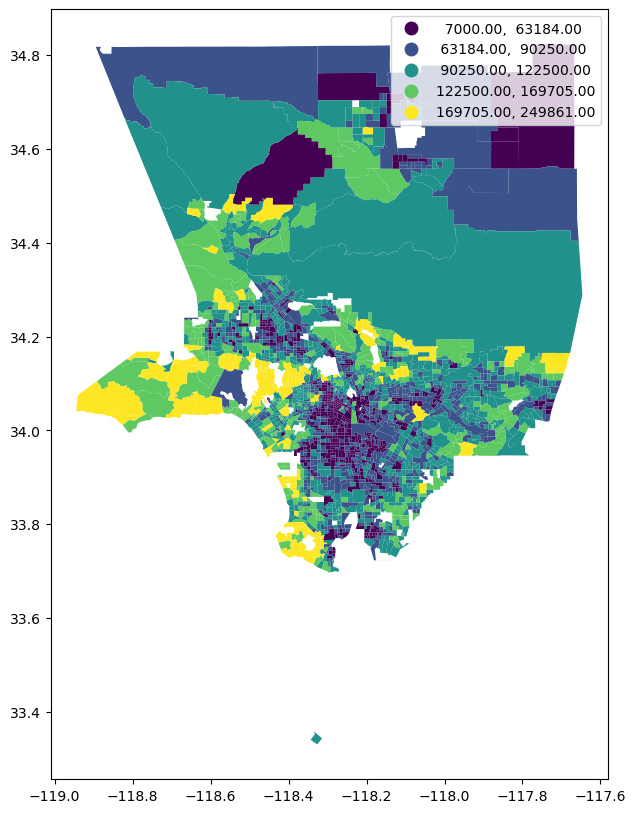

In [34]:
tracts_income.plot(figsize=(12,10),
                 column='MedHHIncome_All',
                 legend=True, 
                 scheme='naturalbreaks')

<Axes: >

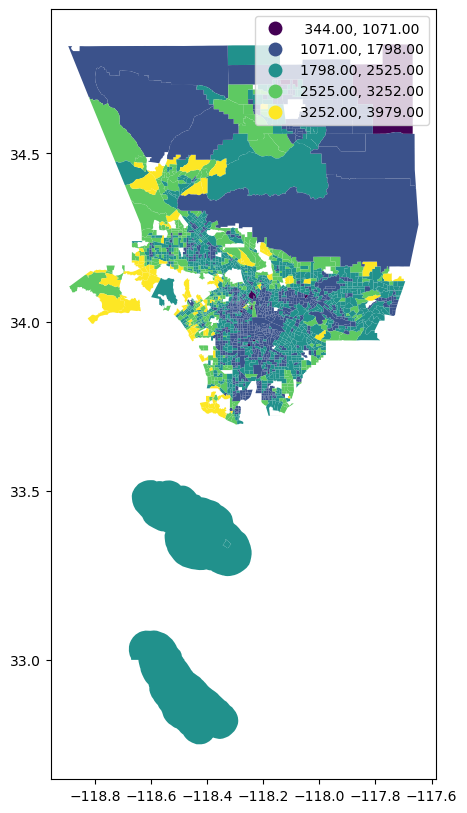

In [35]:
tracts_income.plot(figsize=(12,10),
                 column='MonthlyCosts_All',
                 legend=True, 
                 scheme='equal_interval')

### I am interested in plotting monthly housing costs as a percentage of monthly income

In [36]:
#Adding new column: # Avoid division by zero (replace zero or NaN incomes with NaN)
tracts_income["HousingCostPercentage"] = (
    (tracts_income["MonthlyCosts_All"] / (tracts_income["MedHHIncome_All"] / 12)) * 100
)


<Axes: >

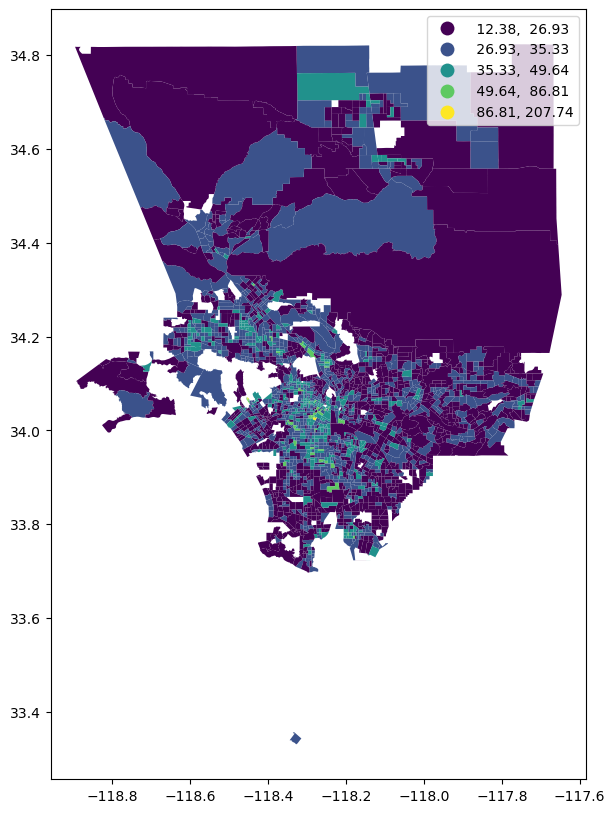

In [37]:
tracts_income.plot(figsize=(12,10),
                 column='HousingCostPercentage',
                 legend=True, 
                 scheme='naturalbreaks')

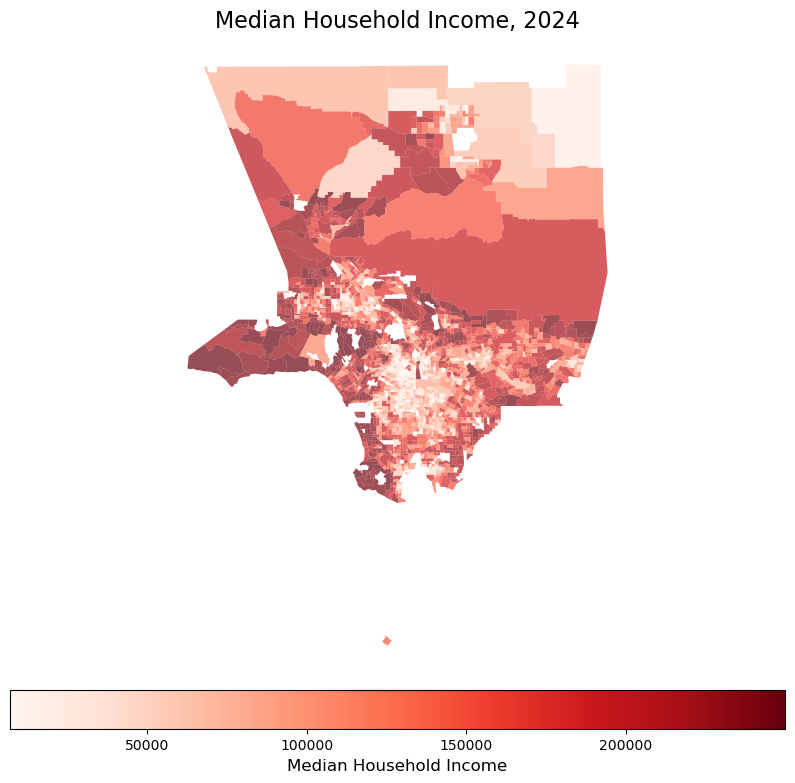

FileNotFoundError: [Errno 2] No such file or directory: '/home/jovyan/221-final-project/Group Assignments/Income/221-final-project/Group Assignments/Income/medHHincomeLAplot.jpg'

<Figure size 640x480 with 0 Axes>

In [38]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib as mpl

# Assuming 'tracts_income' is already your GeoDataFrame

# Create the figure and axis with adjusted size
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the data, using the 'MedHHIncome_All' column to set the color
# Use 'Reds' or any other color map you prefer
gdf_plot = tracts_income.plot(
    ax=ax,
    column='MedHHIncome_All',  # Column to be used for coloring
    cmap='Reds',  # Color map for gradient
    legend=False,  # Disable default legend
    alpha=0.7  # Make the polygons slightly transparent for better visibility
)

# Add a colorbar (this acts as the gradient bar)
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=tracts_income['MedHHIncome_All'].min(), vmax=tracts_income['MedHHIncome_All'].max()))
sm.set_array([])  # We don't need any data associated with the colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Median Household Income', fontsize=12)

# Title and styling
ax.set_title('Median Household Income, 2024', fontsize=16)
ax.axis('off')  # Remove axis for better visualization

# Save the plot to a file with adjusted DPI and size
plt.savefig('MedHHIncome.jpg', dpi=150, bbox_inches='tight')

# Show the plot
plt.show()

plt.savefig('221-final-project/Group Assignments/Income/medHHincomeLAplot.jpg', dpi=150)

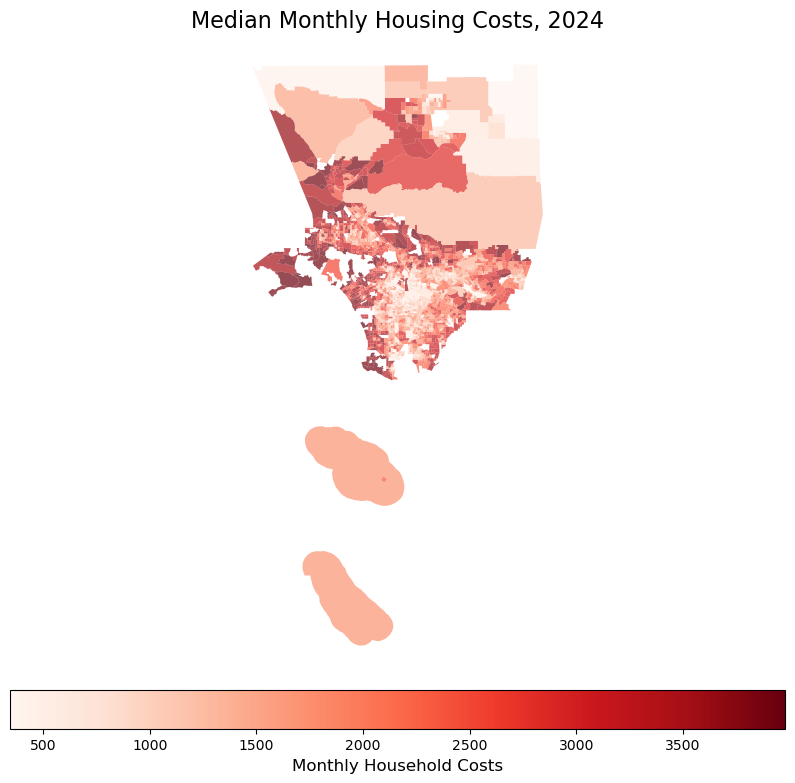

In [39]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the data, using the 'MedHHIncome_All' column to set the color
# Use 'Reds' or any other color map you prefer
gdf_plot = tracts_income.plot(
    ax=ax,
    column='MonthlyCosts_All',  # Column to be used for coloring
    cmap='Reds',  # Color map for gradient
    legend=False,  # Disable default legend
    alpha=0.7  # Make the polygons slightly transparent for better visibility
)

# Add a colorbar (this acts as the gradient bar)
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=tracts_income['MonthlyCosts_All'].min(), vmax=tracts_income['MonthlyCosts_All'].max()))
sm.set_array([])  # We don't need any data associated with the colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Monthly Household Costs', fontsize=12)

# Title and styling
ax.set_title('Median Monthly Housing Costs, 2024', fontsize=16)
ax.axis('off')  # Remove axis for better visualization

# Save the plot to a file with adjusted DPI and size
plt.savefig('MedHHCosts.jpg', dpi=150, bbox_inches='tight')

# Show the plot
plt.show()


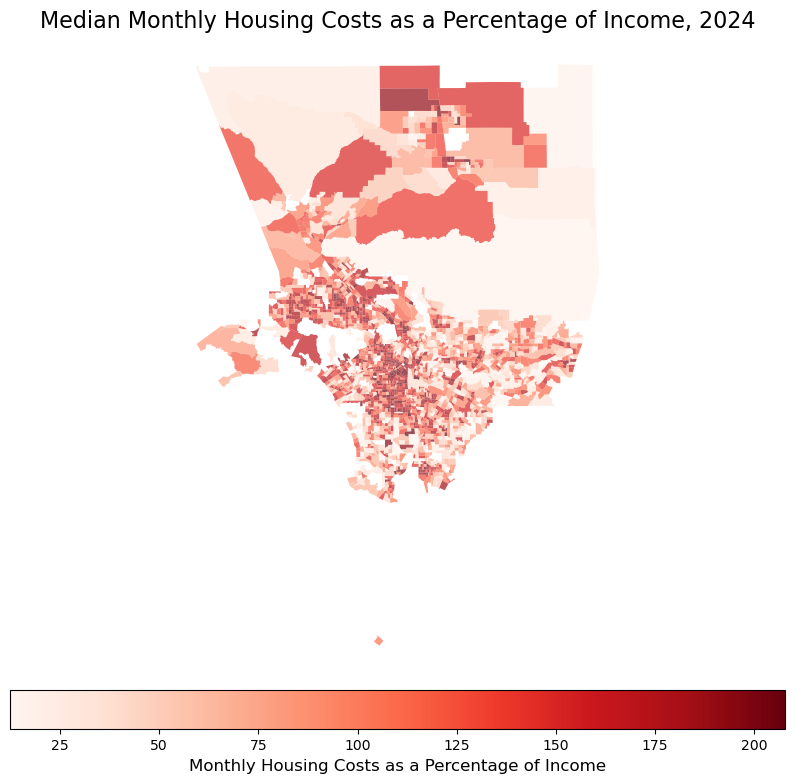

In [40]:
fig, ax = plt.subplots(figsize=(10, 10))

# Plot the data, using the 'MedHHIncome_All' column to set the color
# Use 'Reds' or any other color map you prefer
gdf_plot = tracts_income.plot(
    ax=ax,
    column='HousingCostPercentage',  # Column to be used for coloring
    cmap='Reds',  # Color map for gradient
    legend=False,  # Disable default legend
    alpha=0.7  # Make the polygons slightly transparent for better visibility
)

# Add a colorbar (this acts as the gradient bar)
sm = plt.cm.ScalarMappable(cmap='Reds', norm=plt.Normalize(vmin=tracts_income['HousingCostPercentage'].min(), vmax=tracts_income['HousingCostPercentage'].max()))
sm.set_array([])  # We don't need any data associated with the colorbar
cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
cbar.set_label('Monthly Housing Costs as a Percentage of Income', fontsize=12)

# Title and styling
ax.set_title('Median Monthly Housing Costs as a Percentage of Income, 2024', fontsize=16)
ax.axis('off')  # Remove axis for better visualization

# Save the plot to a file with adjusted DPI and size
plt.savefig('MedHHCostsIncome.jpg', dpi=150, bbox_inches='tight')

# Show the plot
plt.show()


In [41]:
df2.sample()

,FIPS,MedHHIncome_All,MonthlyCosts_All,MedHHIncome_OwnerOccupied,MonthlyCosts_OwnerOccupied,MedHHIncome_RenterOccupied,MonthlyCosts_RenterOccupied,MedHHIncome_Mixed,MonthlyCosts_Mixed,MedHHIncome_NoMortgage,MonthlyCosts_NoMortgage,MedHHIncome_Mortgage,MonthlyCosts_Mortgage
150,06037119341,53623.0,1967.0,53623.0,1967.0,113125.0,2091.0,113125.0,2091.0,35909.0,1900.0,35909.0,1900.0


In [42]:
print(tracts_income.columns)

Index(['CT20', 'geometry', 'FIPS', 'MedHHIncome_All', 'MonthlyCosts_All',
       'MedHHIncome_OwnerOccupied', 'MonthlyCosts_OwnerOccupied',
       'MedHHIncome_RenterOccupied', 'MonthlyCosts_RenterOccupied',
       'MedHHIncome_Mixed', 'MonthlyCosts_Mixed', 'MedHHIncome_NoMortgage',
       'MonthlyCosts_NoMortgage', 'MedHHIncome_Mortgage',
       'MonthlyCosts_Mortgage', 'HousingCostPercentage'],
      dtype='object')


In [43]:
tracts_income.sample(1)

,CT20,geometry,FIPS,MedHHIncome_All,MonthlyCosts_All,MedHHIncome_OwnerOccupied,MonthlyCosts_OwnerOccupied,MedHHIncome_RenterOccupied,MonthlyCosts_RenterOccupied,MedHHIncome_Mixed,MonthlyCosts_Mixed,MedHHIncome_NoMortgage,MonthlyCosts_NoMortgage,MedHHIncome_Mortgage,MonthlyCosts_Mortgage,HousingCostPercentage
119,115202,"POLYGON ((-118.52736 34.23002, -118.52736 34.2...",06037115202,66679.0,2214.0,66679.0,2214.0,122000.0,2794.0,122000.0,2794.0,49074.0,2121.0,49074.0,2121.0,39.844629


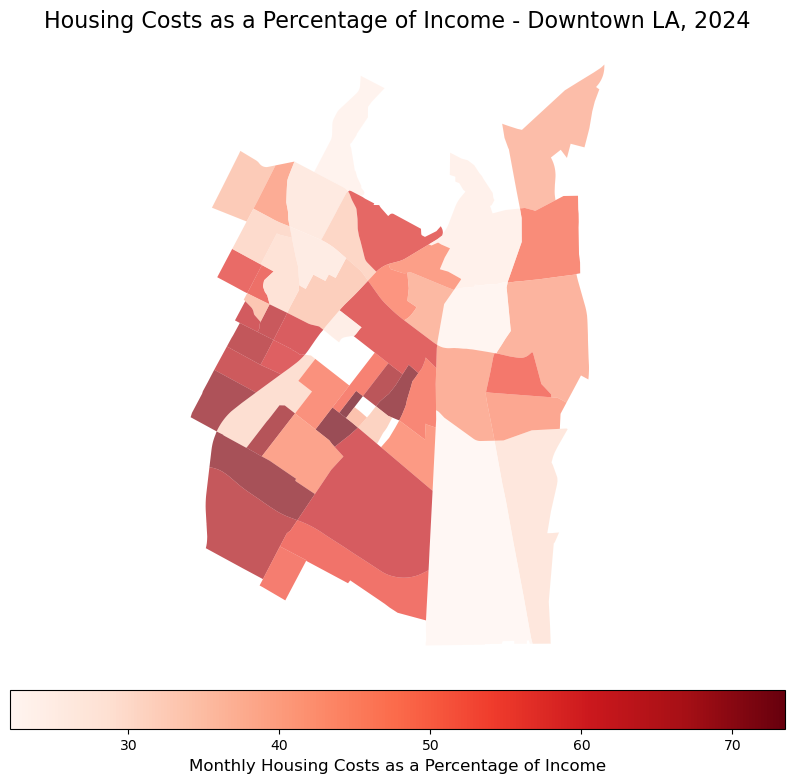

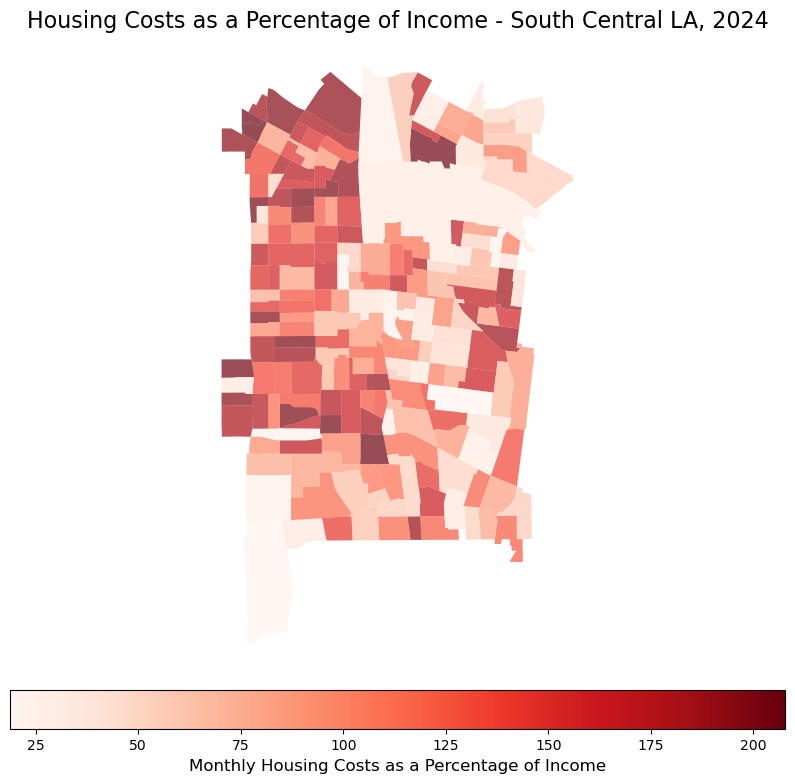

In [44]:
import matplotlib.pyplot as plt
import geopandas as gpd
import os  # To check and create directories if needed

# Define bounding boxes for Downtown LA and South Central LA
downtown_bounds = [-118.2673, 34.027, -118.2257, 34.076]  # [min_long, min_lat, max_long, max_lat]
south_central_bounds = [-118.28, 33.9, -118.18, 34.03]  # [min_long, min_lat, max_long, max_lat]

# Function to filter GeoDataFrame based on bounding box
def filter_by_bounding_box(gdf, bounds):
    min_long, min_lat, max_long, max_lat = bounds
    return gdf.cx[min_long:max_long, min_lat:max_lat]

# Plotting function
def plot_static_map(gdf, title, filename, cmap='Reds', bounds=None):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Apply bounding box if provided
    if bounds:
        gdf = filter_by_bounding_box(gdf, bounds)

    # Plot the data, using the 'HousingCostPercentage' column to set the color
    gdf.plot(
        ax=ax,
        column='HousingCostPercentage',  # Column to be used for coloring
        cmap=cmap,  # Color map for gradient
        legend=False,  # Disable default legend
        alpha=0.7  # Make the polygons slightly transparent for better visibility
    )

    # Add a colorbar (this acts as the gradient bar)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=gdf['HousingCostPercentage'].min(), vmax=gdf['HousingCostPercentage'].max()))
    sm.set_array([])  # We don't need any data associated with the colorbar
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
    cbar.set_label('Monthly Housing Costs as a Percentage of Income', fontsize=12)

    # Title and styling
    ax.set_title(title, fontsize=16)
    ax.axis('off')  # Remove axis for better visualization

    # Ensure the output directory exists
    output_dir = os.path.dirname(filename)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Save the plot to a file with adjusted DPI and size
    plt.savefig(filename, dpi=150, bbox_inches='tight')

    # Show the plot
    plt.show()


# File paths for saving
downtown_filename = '/home/jovyan/work/output/downtown_housing_costs.jpg'
south_central_filename = '/home/jovyan/work/output/south_central_housing_costs.jpg'

# Plot Downtown LA (using bounding box for zooming)
plot_static_map(tracts_income, "Housing Costs as a Percentage of Income - Downtown LA, 2024", downtown_filename, bounds=downtown_bounds)

# Plot South Central LA (using bounding box for zooming)
plot_static_map(tracts_income, "Housing Costs as a Percentage of Income - South Central LA, 2024", south_central_filename, bounds=south_central_bounds)


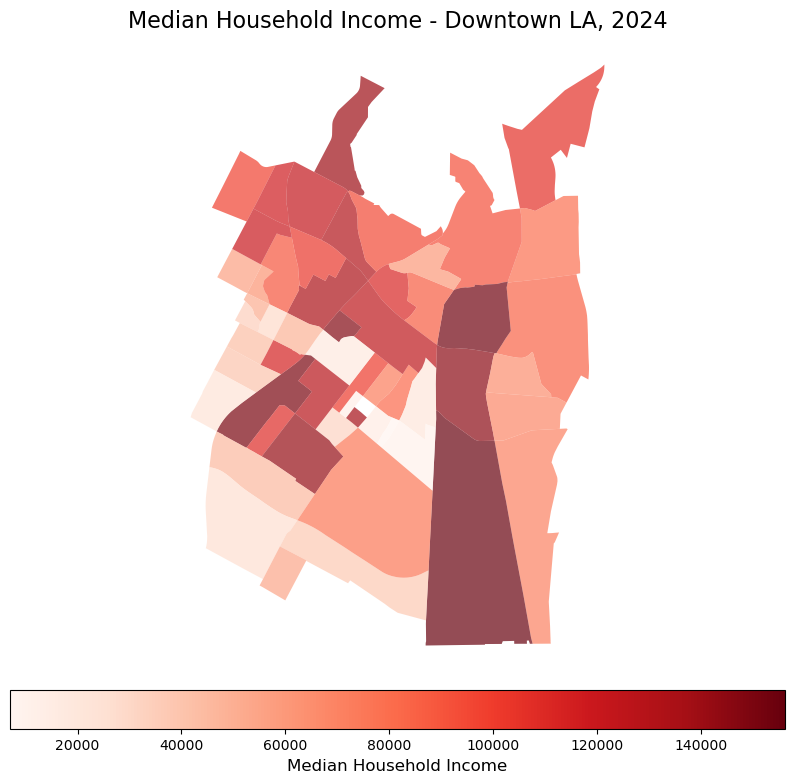

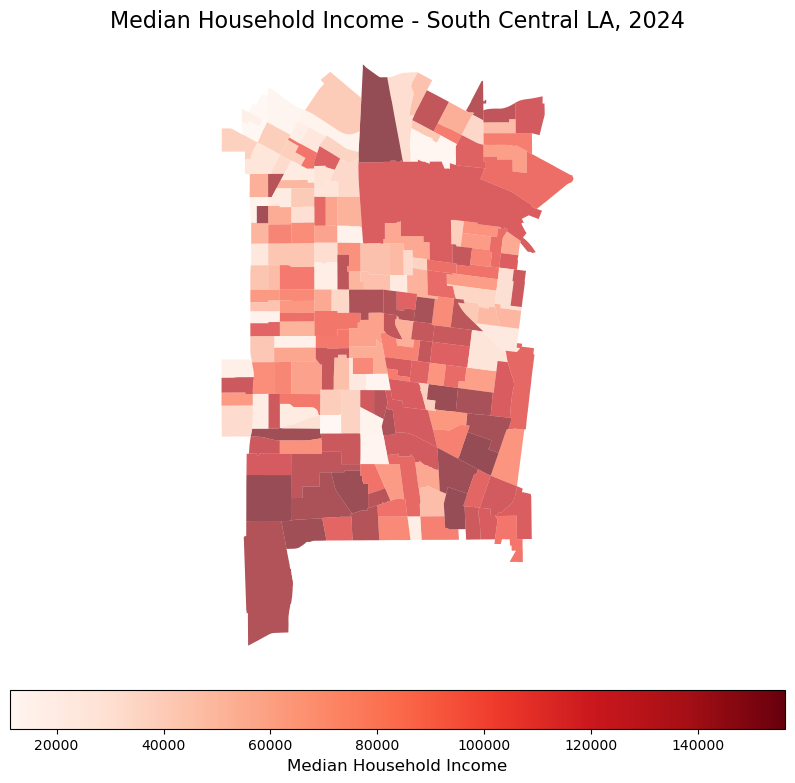

In [45]:
import matplotlib.pyplot as plt
import geopandas as gpd
import matplotlib as mpl
import os  # To check and create directories if needed

# Define bounding boxes for Downtown LA and South Central LA
downtown_bounds = [-118.2673, 34.027, -118.2257, 34.076]  # [min_long, min_lat, max_long, max_lat]
south_central_bounds = [-118.28, 33.9, -118.18, 34.03]  # [min_long, min_lat, max_long, max_lat]

# Function to filter GeoDataFrame based on bounding box
def filter_by_bounding_box(gdf, bounds):
    min_long, min_lat, max_long, max_lat = bounds
    return gdf.cx[min_long:max_long, min_lat:max_lat]

# Plotting function
def plot_static_map(gdf, title, filename, cmap='Reds', bounds=None):
    fig, ax = plt.subplots(figsize=(10, 10))

    # Apply bounding box if provided
    if bounds:
        gdf = filter_by_bounding_box(gdf, bounds)

    # Plot the data, using the 'MedHHIncome_All' column to set the color
    gdf.plot(
        ax=ax,
        column='MedHHIncome_All',  # Column to be used for coloring
        cmap=cmap,  # Color map for gradient
        legend=False,  # Disable default legend
        alpha=0.7  # Make the polygons slightly transparent for better visibility
    )

    # Add a colorbar (this acts as the gradient bar)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=gdf['MedHHIncome_All'].min(), vmax=gdf['MedHHIncome_All'].max()))
    sm.set_array([])  # We don't need any data associated with the colorbar
    cbar = plt.colorbar(sm, ax=ax, orientation='horizontal', pad=0.02)
    cbar.set_label('Median Household Income', fontsize=12)

    # Title and styling
    ax.set_title(title, fontsize=16)
    ax.axis('off')  # Remove axis for better visualization

    # Ensure the output directory exists
    output_dir = os.path.dirname(filename)
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)

    # Save the plot to a file with adjusted DPI and size
    plt.savefig(filename, dpi=150, bbox_inches='tight')

    # Show the plot
    plt.show()


# File paths for saving
downtown_filename = '/home/jovyan/work/output/downtown_housing_income.jpg'
south_central_filename = '/home/jovyan/work/output/south_central_housing_income.jpg'

# Plot Downtown LA (using bounding box for zooming)
plot_static_map(tracts_income, "Median Household Income - Downtown LA, 2024", downtown_filename, bounds=downtown_bounds)

# Plot South Central LA (using bounding box for zooming)
plot_static_map(tracts_income, "Median Household Income - South Central LA, 2024", south_central_filename, bounds=south_central_bounds)


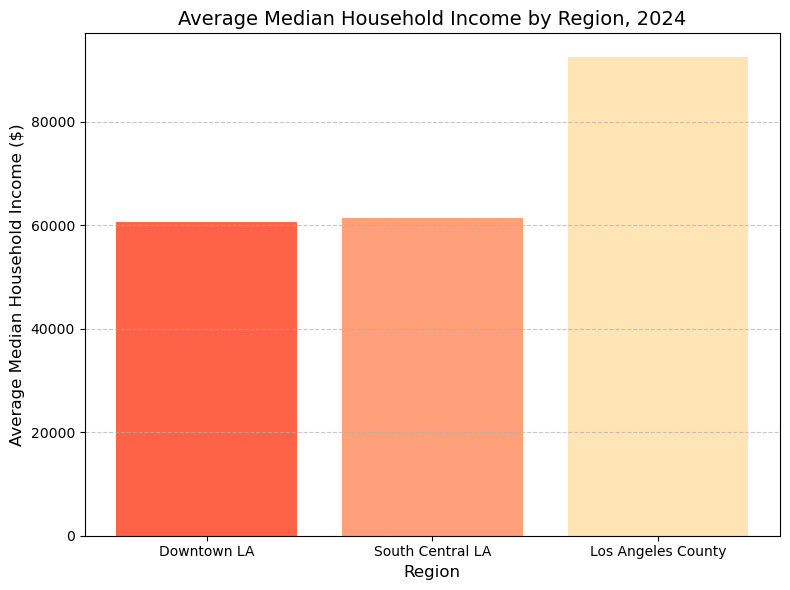

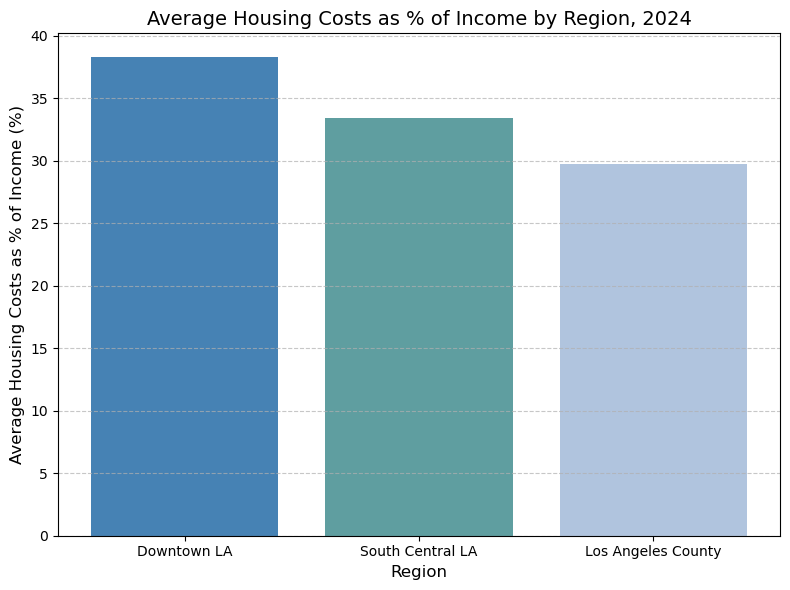

In [46]:
import matplotlib.pyplot as plt
import pandas as pd

# Function to calculate average values for a specific column within a bounding box
def calculate_average_within_bounds(gdf, column, bounds):
    filtered_gdf = filter_by_bounding_box(gdf, bounds)
    return filtered_gdf[column].mean()

# Calculate averages for each region
average_income_downtown = calculate_average_within_bounds(tracts_income, 'MedHHIncome_All', downtown_bounds)
average_income_south_central = calculate_average_within_bounds(tracts_income, 'MedHHIncome_All', south_central_bounds)
average_income_la_county = tracts_income['MedHHIncome_All'].mean()

average_housing_costs_downtown = calculate_average_within_bounds(tracts_income, 'HousingCostPercentage', downtown_bounds)
average_housing_costs_south_central = calculate_average_within_bounds(tracts_income, 'HousingCostPercentage', south_central_bounds)
average_housing_costs_la_county = tracts_income['HousingCostPercentage'].mean()

# Create dataframes for plotting
income_data = pd.DataFrame({
    "Region": ["Downtown LA", "South Central LA", "Los Angeles County"],
    "Average Median Household Income": [
        average_income_downtown,
        average_income_south_central,
        average_income_la_county
    ]
})

housing_costs_data = pd.DataFrame({
    "Region": ["Downtown LA", "South Central LA", "Los Angeles County"],
    "Average Housing Costs as % of Income": [
        average_housing_costs_downtown,
        average_housing_costs_south_central,
        average_housing_costs_la_county
    ]
})

# Plot Average Median Household Income
plt.figure(figsize=(8, 6))
plt.bar(income_data["Region"], income_data["Average Median Household Income"], color=['#FF6347', '#FFA07A', '#FFE4B5'])
plt.title("Average Median Household Income by Region, 2024", fontsize=14)
plt.ylabel("Average Median Household Income ($)", fontsize=12)
plt.xlabel("Region", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/home/jovyan/work/output/average_income_comparison.jpg', dpi=150)
plt.show()

# Plot Average Housing Costs as % of Income
plt.figure(figsize=(8, 6))
plt.bar(housing_costs_data["Region"], housing_costs_data["Average Housing Costs as % of Income"], color=['#4682B4', '#5F9EA0', '#B0C4DE'])
plt.title("Average Housing Costs as % of Income by Region, 2024", fontsize=14)
plt.ylabel("Average Housing Costs as % of Income (%)", fontsize=12)
plt.xlabel("Region", fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('/home/jovyan/work/output/average_housing_costs_comparison.jpg', dpi=150)
plt.show()


### Plotting live arrest data onto Average Median Income map

In [47]:
import pandas as pd
import plotly.express as px
from sodapy import Socrata

In [48]:
client = Socrata("data.lacity.org", None)
results = client.get("amvf-fr72", limit=2000) #get us the API unique identifier, from the URL or API endpoint
arrests = pd.DataFrame.from_records(results) #note that "results" is the variable input for the data
arrests.sample(2)

,rpt_id,report_type,arst_date,time,area,area_desc,rd,age,sex_cd,descent_cd,chrg_grp_cd,grp_description,arst_typ_cd,charge,chrg_desc,dispo_desc,location,lat,lon,location_1,bkg_date,bkg_time,bkg_location,bkg_loc_cd,:@computed_region_qz3q_ghft,:@computed_region_k96s_3jcv,:@computed_region_tatf_ua23,:@computed_region_ur2y_g4cx,:@computed_region_kqwf_mjcx,:@computed_region_2dna_qi2s,crsst
483,230123499,RFC,2023-11-06T00:00:00.000,2330,01,Central,0152,45,M,H,24,Miscellaneous Other Violations,M,369I(B)1PC,ENTER RAILROAD PROPERTY HINDER OPERATION,MISDEMEANOR COMPLAINT FILED,600 S FIGUEROA ST,34.0508,-118.2586,"{'type': 'Point', 'coordinates': [-118.2586, 3...",NaN,NaN,NaN,NaN,23078,546,733,NaN,9,76,NaN
365,6644979,BOOKING,2023-07-21T00:00:00.000,0715,06,Hollywood,0636,30,M,W,04,Aggravated Assault,F,273.5(A)PC,CORPORAL INJURY ON SPOUSE/COHABITANT/ETC,CITY ATTORNEY REJECT,1800 N WILCOX AV,34.1039,-118.331,"{'type': 'Point', 'coordinates': [-118.331, 34...",2023-07-21T00:00:00.000,0817,HOLLYWOOD,4206,23446,415,334,NaN,8,82,NaN


In [49]:
from datetime import datetime
start_date = f"{datetime.now().year}-01-01T00:00:00"
end_date = datetime.now().strftime("%Y-%m-%dT%H:%M:%S")

# Get data from the API with live date range
results = client.get(
    "amvf-fr72", 
    limit=5000, 
    where=f"arst_date between '{start_date}' and '{end_date}'"
)

import pandas as pd
dfa = pd.DataFrame.from_records(results)

# Display the first few rows
print(dfa.head())

    rpt_id report_type                arst_date  time area    area_desc    rd  \
0  6945486     BOOKING  2025-01-01T00:00:00.000  2030   13       Newton  1371   
1  6945475     BOOKING  2025-01-01T00:00:00.000  1825   10  West Valley  1025   
2  6945170     BOOKING  2025-01-01T00:00:00.000  0735   06    Hollywood  0636   
3  6945153     BOOKING  2025-01-01T00:00:00.000  0630   01      Central  0182   
4  6945402     BOOKING  2025-01-01T00:00:00.000  0930   17   Devonshire  1794   

  age sex_cd descent_cd chrg_grp_cd                 grp_description  \
0  30      M          B          12             Weapon (carry/poss)   
1  58      M          H          08                  Other Assaults   
2  38      F          B          22         Driving Under Influence   
3  29      M          B          24  Miscellaneous Other Violations   
4  38      M          W          06                         Larceny   

  arst_typ_cd       charge                                   chrg_desc  \
0           

In [50]:
dfa.sample(5)

,rpt_id,report_type,arst_date,time,area,area_desc,rd,age,sex_cd,descent_cd,chrg_grp_cd,grp_description,arst_typ_cd,charge,chrg_desc,dispo_desc,location,crsst,lat,lon,location_1,bkg_date,bkg_time,bkg_location,bkg_loc_cd
197,6945955,BOOKING,2025-01-02T00:00:00.000,1802,19,Mission,1918,46,M,H,22,Driving Under Influence,M,23152(F)VC,DUI OF ANY DRUG,MISDEMEANOR COMPLAINT FILED,FOOTHILL,MACLAY,34.2985,-118.4205,"{'type': 'Point', 'coordinates': [-118.4205, 3...",2025-01-02T00:00:00.000,2133,VALLEY - JAIL DIV,4279
661,6947507,BOOKING,2025-01-05T00:00:00.000,1655,21,Topanga,2144,34,M,H,16,Narcotic Drug Laws,F,11395(B)1HS,POSS CNTL SUB W/2 + PRIOR CONVICTIONS,MISDEMEANOR COMPLAINT FILED,VANOWEN,SHOUP,34.1937,-118.6146,"{'type': 'Point', 'coordinates': [-118.6146, 3...",2025-01-05T00:00:00.000,2000,VALLEY - JAIL DIV,4279
2762,6957658,BOOKING,2025-01-25T00:00:00.000,0619,15,N Hollywood,1513,31,M,H,22,Driving Under Influence,M,23152(A)VC,DRUNK DRIVING ALCOHOL/DRUGS,NaN,ROSCOE BL,HOLLYWOOD FY,34.1966,-118.4061,"{'type': 'Point', 'coordinates': [-118.4061, 3...",2025-01-25T00:00:00.000,0806,VALLEY - JAIL DIV,4279
1781,6952922,BOOKING,2025-01-16T00:00:00.000,1155,09,Van Nuys,0935,33,M,B,04,Aggravated Assault,M,273.5(A)PC,CORPORAL INJURY ON SPOUSE/COHABITANT/ETC,NaN,14400 ERWIN ST,NaN,34.1837,-118.4422,"{'type': 'Point', 'coordinates': [-118.4422, 3...",2025-01-16T00:00:00.000,1210,VALLEY - JAIL DIV,4279
887,6948278,BOOKING,2025-01-07T00:00:00.000,0345,01,Central,0134,30,M,O,04,Aggravated Assault,F,273.5(A)PC,CORPORAL INJURY ON SPOUSE/COHABITANT/ETC,DISTRICT ATTORNEY REJECT,300 S SPRING ST,NaN,34.0502,-118.2487,"{'type': 'Point', 'coordinates': [-118.2487, 3...",2025-01-07T00:00:00.000,0604,METRO - JAIL DIVISION,4273


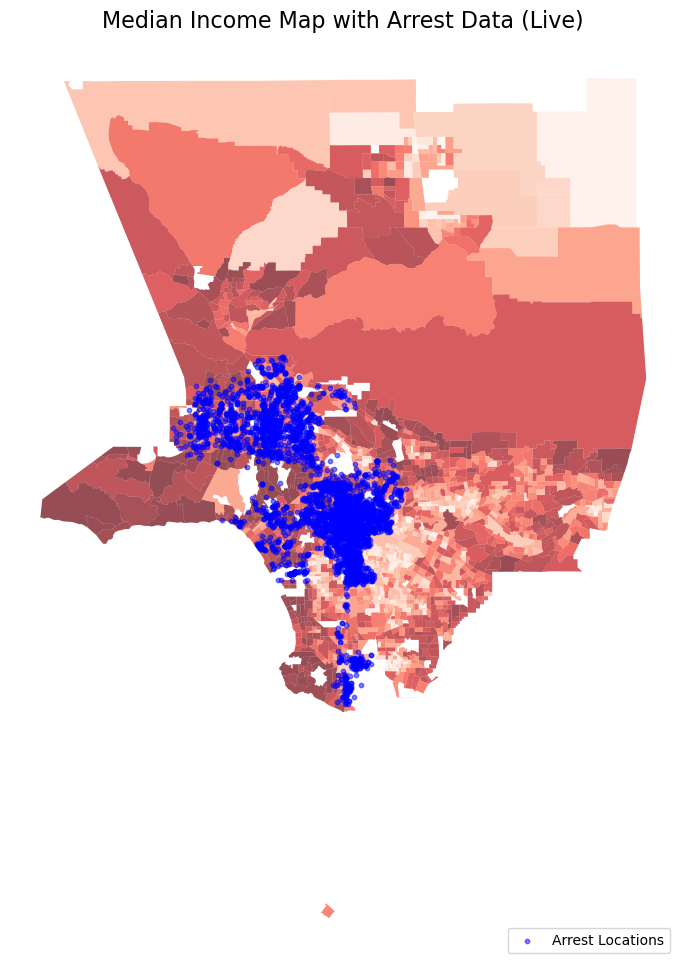

In [51]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import Point

# Step 1: Fetch live arrest data
from sodapy import Socrata
from datetime import datetime

client = Socrata("data.lacity.org", None)  

# Get live arrest data from Jan 1 to now
results = client.get(
    "amvf-fr72",
    limit=5000,
    where=f"arst_date between '{datetime.now().year}-01-01T00:00:00' and '{datetime.now().isoformat()}'"
)

# Convert to DataFrame
arrest_df = pd.DataFrame.from_records(results)

# Step 2: Prepare GeoDataFrame for arrest data
# Ensure latitude and longitude columns exist
arrest_df['latitude'] = arrest_df['lat'].astype(float)
arrest_df['longitude'] = arrest_df['lon'].astype(float)

# Create a GeoDataFrame
geometry = [Point(xy) for xy in zip(arrest_df['lon'], arrest_df['lat'])]
arrest_gdf = gpd.GeoDataFrame(arrest_df, geometry=geometry, crs="EPSG:4326")  # Use WGS84 CRS (common for GPS)

# Reproject to match income data CRS
arrest_gdf = arrest_gdf.to_crs(tracts_income.crs)

# Step 3: Plot income map with arrest data overlay
fig, ax = plt.subplots(figsize=(12, 12))

# Plot median income
tracts_income.plot(
    ax=ax,
    column='MedHHIncome_All',
    cmap='Reds',
    legend=True,
    alpha=0.7
)

# Overlay arrest points
arrest_gdf.plot(
    ax=ax,
    color='blue',
    markersize=10,
    alpha=0.5,
    label="Arrest Locations"
)

# Add labels and legend
ax.set_title('Median Income Map with Arrest Data (Live)', fontsize=16)
ax.legend(loc='lower right', fontsize=10)
ax.axis('off')

# Save and show plot
plt.savefig("income_arrest_map.jpg", dpi=150, bbox_inches='tight')
plt.show()


In [53]:
def isomap():    
    results = client.get(
        "amvf-fr72",
        limit=5000,
        where=f"arst_date between '{datetime.now().year}-01-01T00:00:00' and '{datetime.now().isoformat()}'"
    )
    
    # Convert to DataFrame
    arrest_df = pd.DataFrame.from_records(results)
    
    # Step 2: Prepare GeoDataFrame for arrest data
    # Ensure latitude and longitude columns exist
    arrest_df['latitude'] = arrest_df['lat'].astype(float)
    arrest_df['longitude'] = arrest_df['lon'].astype(float)
    
    # Create a GeoDataFrame
    geometry = [Point(xy) for xy in zip(arrest_df['lon'], arrest_df['lat'])]
    arrest_gdf = gpd.GeoDataFrame(arrest_df, geometry=geometry, crs="EPSG:4326")  # Use WGS84 CRS (common for GPS)
    
    # Reproject to match income data CRS
    arrest_gdf = arrest_gdf.to_crs(tracts_income.crs)
    
    # Step 3: Plot income map with arrest data overlay
    fig, ax = plt.subplots(figsize=(12, 12))
    
    # Plot median income
    tracts_income.plot(
        ax=ax,
        column='HousingCostPercentage',
        cmap='Reds',
        legend=True,
        alpha=0.7
    )
    
    # Overlay arrest points
    arrest_gdf.plot(
        ax=ax,
        color='blue',
        markersize=10,
        alpha=0.5,
        label="Arrest Locations"
    )
    
    # Add labels and legend
    ax.set_title('Housing Costs as a Percentage of Income with Arrest Data (Live)', fontsize=16)
    ax.legend(loc='lower right', fontsize=10)
    ax.axis('off')
    
    # Save and show plot
    plt.savefig("housing_costs_arrest_map.jpg", dpi=150, bbox_inches='tight')
    plt.show()

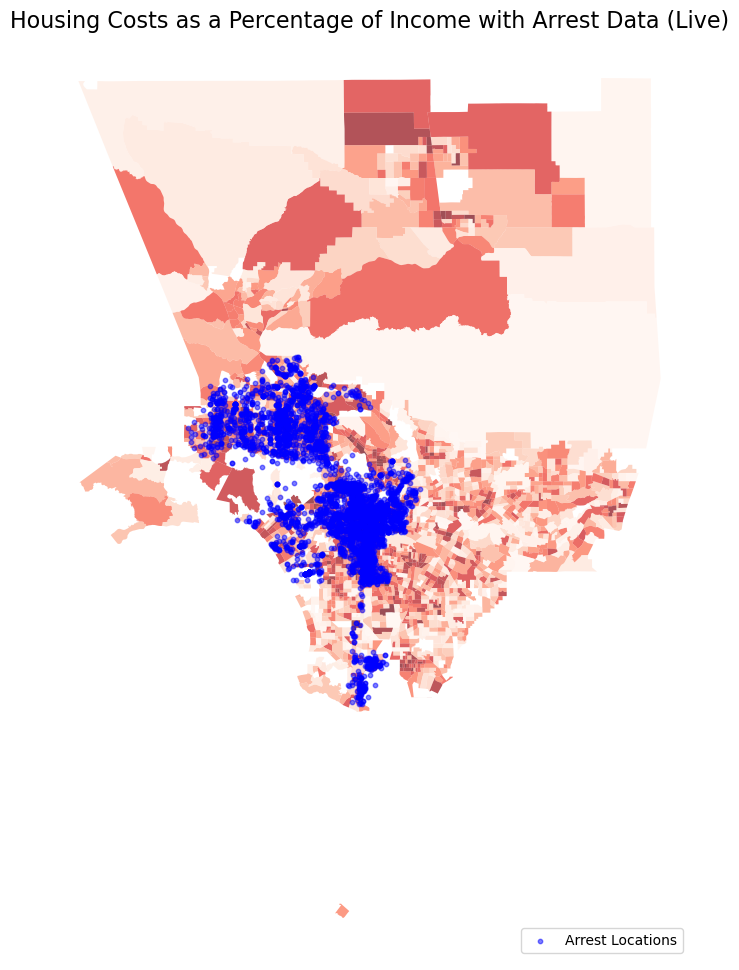

In [54]:
isomap()

Generating map for Downtown LA...


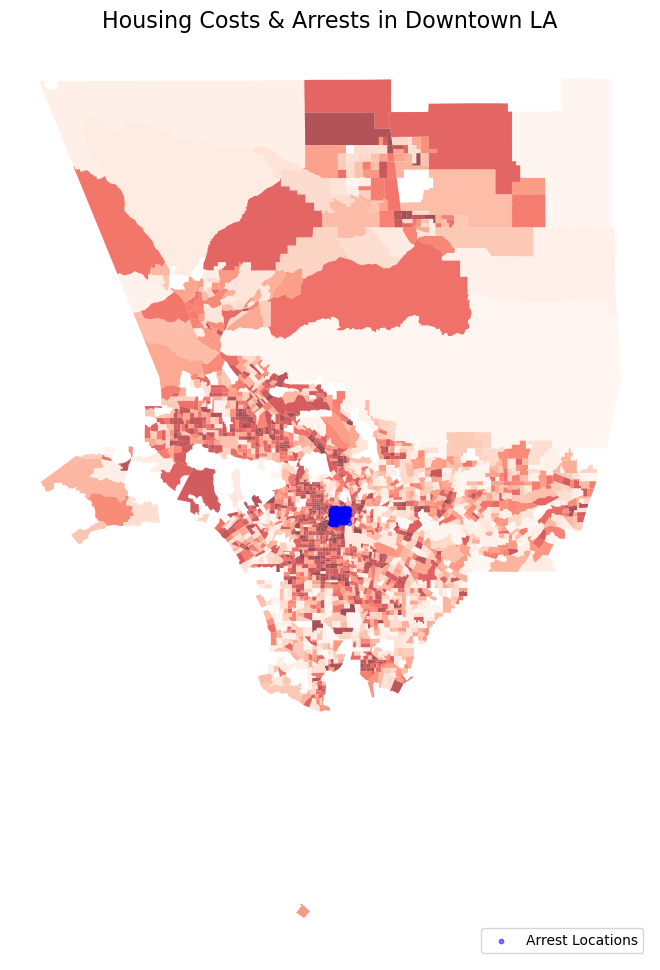

Generating map for South Central LA...


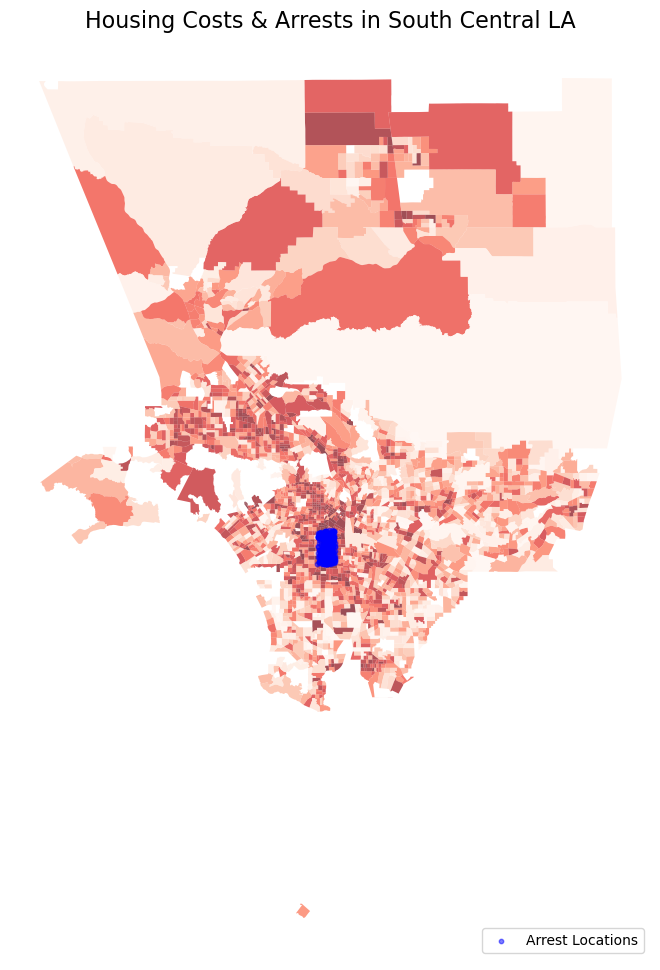

In [55]:
locations = {
    "Downtown LA": {
        "min_lat": 34.03, "max_lat": 34.06,
        "min_lon": -118.27, "max_lon": -118.23
    },
    "South Central LA": {
        "min_lat": 33.96, "max_lat": 34.02,
        "min_lon": -118.30, "max_lon": -118.26
    }
}

def isomap(location_name, min_lat, max_lat, min_lon, max_lon):
    print(f"Generating map for {location_name}...")

    # Step 1: Fetch arrest data within the location and date range
    where_clause = (
        f"arst_date between '{datetime.now().year}-01-01T00:00:00' and '{datetime.now().isoformat()}' "
        f"AND lat BETWEEN {min_lat} AND {max_lat} "
        f"AND lon BETWEEN {min_lon} AND {max_lon}"
    )
    
    results = client.get("amvf-fr72", limit=5000, where=where_clause)
    
    # Convert to DataFrame
    arrest_df = pd.DataFrame.from_records(results)

    # Ensure lat/lon exist
    if 'lat' not in arrest_df or 'lon' not in arrest_df:
        print(f"No data available for {location_name}. Skipping...")
        return
    
    # Convert to float
    arrest_df['latitude'] = arrest_df['lat'].astype(float)
    arrest_df['longitude'] = arrest_df['lon'].astype(float)

    # Create GeoDataFrame
    geometry = [Point(xy) for xy in zip(arrest_df['longitude'], arrest_df['latitude'])]
    arrest_gdf = gpd.GeoDataFrame(arrest_df, geometry=geometry, crs="EPSG:4326")

    # Reproject to match income data CRS
    arrest_gdf = arrest_gdf.to_crs(tracts_income.crs)

    # Step 3: Plot
    fig, ax = plt.subplots(figsize=(12, 12))

    # Plot median income data
    tracts_income.plot(ax=ax, column='HousingCostPercentage', cmap='Reds', legend=True, alpha=0.7)

    # Overlay arrests
    arrest_gdf.plot(ax=ax, color='blue', markersize=10, alpha=0.5, label="Arrest Locations")

    # Add labels and legend
    ax.set_title(f'Housing Costs & Arrests in {location_name}', fontsize=16)
    ax.legend(loc='lower right', fontsize=10)
    ax.axis('off')

    # Save and show plot
    plt.savefig(f"{location_name.replace(' ', '_').lower()}_map.jpg", dpi=150, bbox_inches='tight')
    plt.show()


# **Loop through locations and generate maps**
for name, bounds in locations.items():
    isomap(name, **bounds)

Generating map for Downtown LA...


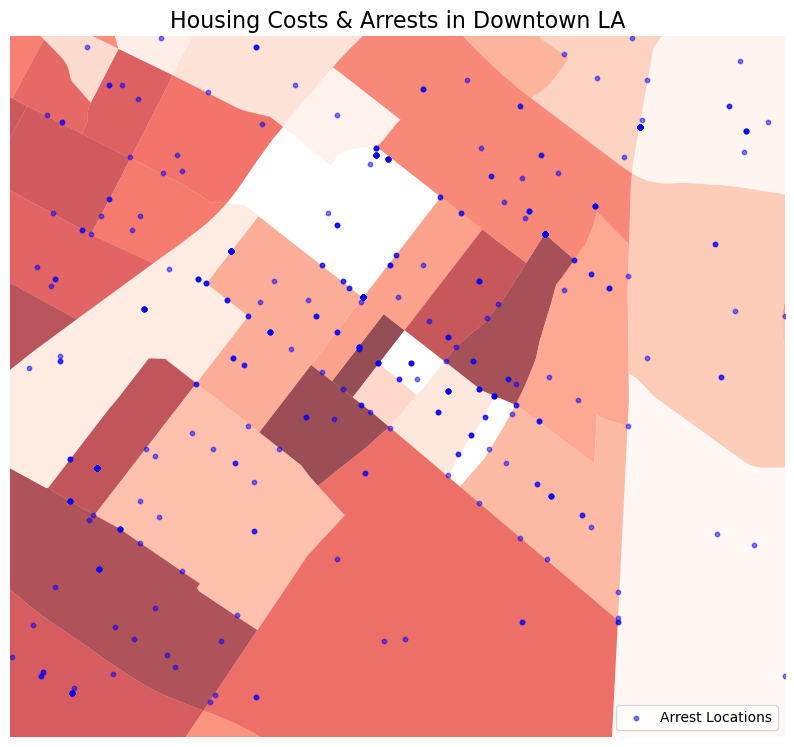

Generating map for South Central LA...


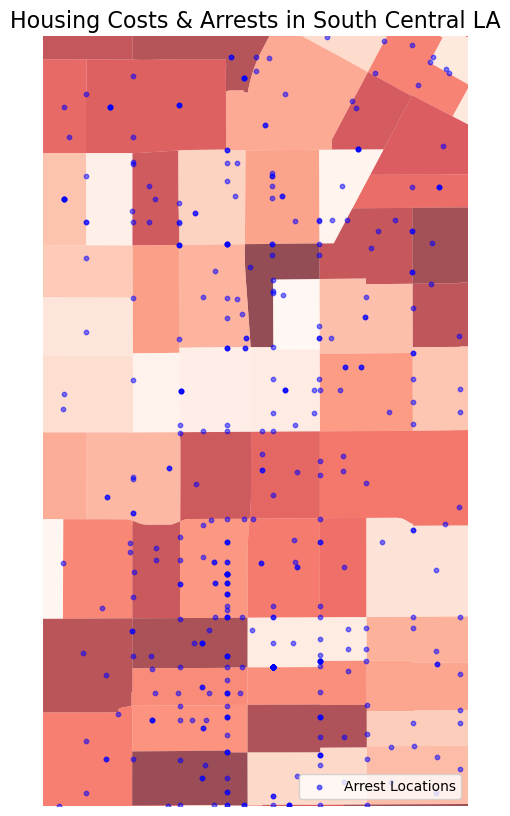

In [56]:
locations = {
    "Downtown LA": {
        "min_lat": 34.03, "max_lat": 34.06,
        "min_lon": -118.27, "max_lon": -118.23
    },
    "South Central LA": {
        "min_lat": 33.96, "max_lat": 34.02,
        "min_lon": -118.30, "max_lon": -118.26
    }
}

def isomap(location_name, min_lat, max_lat, min_lon, max_lon):
    print(f"Generating map for {location_name}...")

    # Step 1: Fetch arrest data within the location and date range
    where_clause = (
        f"arst_date between '{datetime.now().year}-01-01T00:00:00' and '{datetime.now().isoformat()}' "
        f"AND lat BETWEEN {min_lat} AND {max_lat} "
        f"AND lon BETWEEN {min_lon} AND {max_lon}"
    )
    
    results = client.get("amvf-fr72", limit=5000, where=where_clause)
    
    # Convert to DataFrame
    arrest_df = pd.DataFrame.from_records(results)

    # Ensure lat/lon exist
    if 'lat' not in arrest_df or 'lon' not in arrest_df:
        print(f"No data available for {location_name}. Skipping...")
        return
    
    # Convert to float
    arrest_df['latitude'] = arrest_df['lat'].astype(float)
    arrest_df['longitude'] = arrest_df['lon'].astype(float)

    # Create GeoDataFrame
    geometry = [Point(xy) for xy in zip(arrest_df['longitude'], arrest_df['latitude'])]
    arrest_gdf = gpd.GeoDataFrame(arrest_df, geometry=geometry, crs="EPSG:4326")

    # Reproject to match income data CRS
    arrest_gdf = arrest_gdf.to_crs(tracts_income.crs)

    # Step 2: Filter income data to match location
    tracts_income_filtered = tracts_income.cx[min_lon:max_lon, min_lat:max_lat]

    # Step 3: Plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot median income data (only for the given area)
    tracts_income_filtered.plot(ax=ax, column='HousingCostPercentage', cmap='Reds', legend=True, alpha=0.7)

    # Overlay arrests
    arrest_gdf.plot(ax=ax, color='blue', markersize=10, alpha=0.5, label="Arrest Locations")

    # Set zoomed-in view
    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)

    # Add labels and legend
    ax.set_title(f'Housing Costs & Arrests in {location_name}', fontsize=16)
    ax.legend(loc='lower right', fontsize=10)
    ax.axis('off')

    # Save and show plot
    plt.savefig(f"{location_name.replace(' ', '_').lower()}_zoomed_map.jpg", dpi=150, bbox_inches='tight')
    plt.show()


# **Loop through locations and generate zoomed-in maps**
for name, bounds in locations.items():
    isomap(name, **bounds)

In [67]:
import math
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point

from geopy.distance import great_circle

def isomap(location_name, center_lat, center_lon, radius_miles):
    print(f"Generating map for {location_name} within {radius_miles} miles...")

    # Convert miles to degrees (approximate conversion)
    lat_buffer = radius_miles / 69  # 1 degree latitude ≈ 69 miles
    lon_buffer = radius_miles / (69 * abs(math.cos(math.radians(center_lat))))  # Adjust for longitude shrinking toward poles

    # Define bounding box
    min_lat, max_lat = center_lat - lat_buffer, center_lat + lat_buffer
    min_lon, max_lon = center_lon - lon_buffer, center_lon + lon_buffer

    # Step 1: Fetch arrest data within the location and date range
    where_clause = (
        f"arst_date between '{datetime.now().year}-01-01T00:00:00' and '{datetime.now().isoformat()}' "
        f"AND lat BETWEEN {min_lat} AND {max_lat} "
        f"AND lon BETWEEN {min_lon} AND {max_lon}"
    )
    
    results = client.get("amvf-fr72", limit=5000, where=where_clause)
    
    # Convert to DataFrame
    arrest_df = pd.DataFrame.from_records(results)

    # Ensure lat/lon exist
    if 'lat' not in arrest_df or 'lon' not in arrest_df:
        print(f"No data available for {location_name}. Skipping...")
        return
    
    # Convert to float
    arrest_df['latitude'] = arrest_df['lat'].astype(float)
    arrest_df['longitude'] = arrest_df['lon'].astype(float)

    # Create GeoDataFrame
    geometry = [Point(xy) for xy in zip(arrest_df['longitude'], arrest_df['latitude'])]
    arrest_gdf = gpd.GeoDataFrame(arrest_df, geometry=geometry, crs="EPSG:4326")

    # Reproject to match income data CRS
    arrest_gdf = arrest_gdf.to_crs(tracts_income.crs)

    # Step 2: Filter income data to match location
    tracts_income_filtered = tracts_income.cx[min_lon:max_lon, min_lat:max_lat]

    # Step 3: Plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot median income data (only for the given area)
    tracts_income_filtered.plot(ax=ax, column='HousingCostPercentage', cmap='Reds', legend=True, alpha=0.7)

    # Overlay arrests
    arrest_gdf.plot(ax=ax, color='blue', markersize=10, alpha=0.5, label="Arrest Locations")

    # Set zoomed-in view
    ax.set_xlim(min_lon, max_lon)
    ax.set_ylim(min_lat, max_lat)

    # Add labels and legend
    ax.set_title(f'Housing Costs & Arrests in {location_name}', fontsize=16)
    ax.legend(loc='lower right', fontsize=10)
    ax.axis('off')

    # Save and show plot
    plt.savefig(f"{location_name.replace(' ', '_').lower()}_{radius_miles}mi_zoomed_map.jpg", dpi=150, bbox_inches='tight')
    plt.show()


Generating map for Downtown LA within 5 miles...


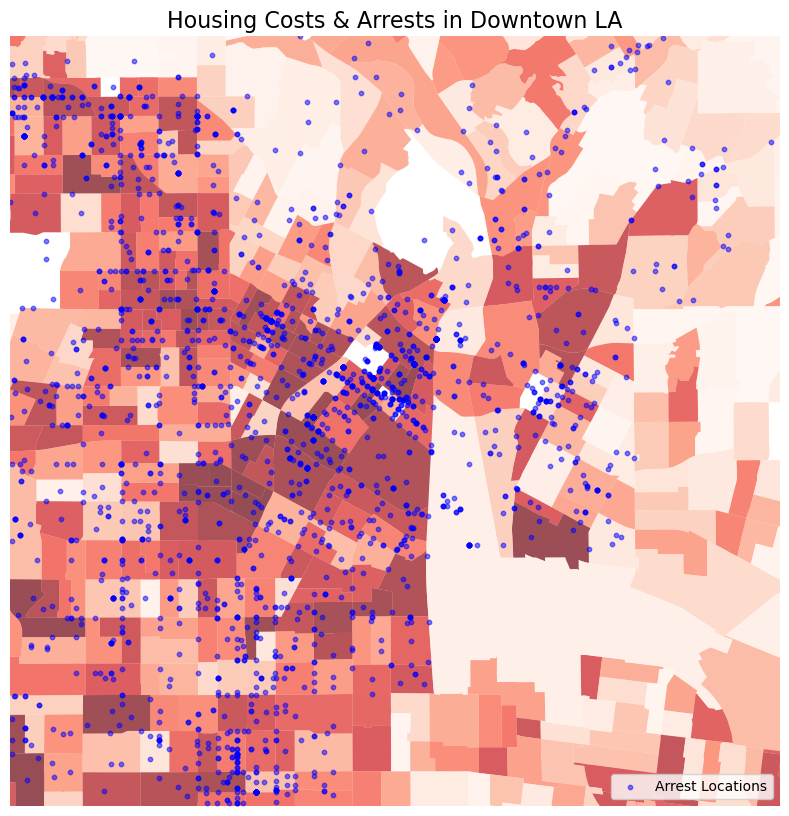

Generating map for South Central LA within 5 miles...


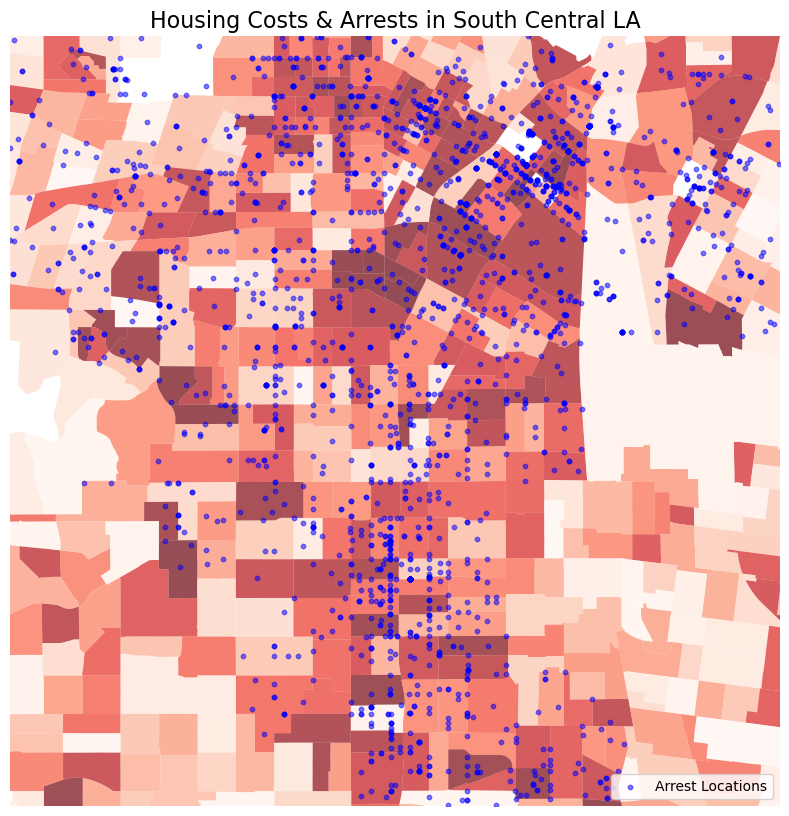

In [70]:
#Downtown: Downtown Los Angeles (DTLA): Latitude: 34.0407 Longitude: -118.2468
#South Central:South Central Los Angeles: Latitude: 34.0006 Longitude: -118.2816
# Define locations with center coordinates and radius
locations = {
    "Downtown LA": {"lat": 34.0407, "lon": -118.2468, "radius": 5},
    "South Central LA": {"lat": 34.0006, "lon": -118.2816, "radius": 5}
}

# Loop through locations and generate maps
for name, info in locations.items():
    isomap(name, info["lat"], info["lon"], info["radius"])